# NCAA March Madness 2026 - Basic EDA

**Objective:** Understand the basic structure of the data - teams, seasons, and game results.

**Outputs:**
- Summary statistics saved to `processed/basic_stats.csv`
- Data quality report
- Basic visualizations

## Setup

In [2]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from src.data_loader import (
    load_teams, load_seasons, load_regular_season_results,
    load_tourney_results, load_seeds, validate_data_coverage
)
from src.utils import check_data_quality, get_season_summary

# Plotting settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## 1. Data Coverage Overview

In [3]:
# Validate men's data coverage
print("MEN'S DATA COVERAGE")
print("=" * 60)
men_coverage = validate_data_coverage('M')
for key, value in men_coverage.items():
    if isinstance(value, list):
        print(f"{key}: {value[0]} to {value[-1]} ({len(value)} seasons)")
    else:
        print(f"{key}: {value}")

MEN'S DATA COVERAGE
num_teams: 381
regular_season_years: 1985 to 2026 (42 seasons)
tournament_years: 1985 to 2025 (40 seasons)
num_regular_games: 196823
num_tourney_games: 2585
seeds_coverage: 1985 to 2025 (40 seasons)


In [4]:
# Validate women's data coverage
print("\nWOMEN'S DATA COVERAGE")
print("=" * 60)
women_coverage = validate_data_coverage('W')
for key, value in women_coverage.items():
    if isinstance(value, list):
        print(f"{key}: {value[0]} to {value[-1]} ({len(value)} seasons)")
    else:
        print(f"{key}: {value}")


WOMEN'S DATA COVERAGE
num_teams: 379
regular_season_years: 1998 to 2026 (29 seasons)
tournament_years: 1998 to 2025 (27 seasons)
num_regular_games: 140825
num_tourney_games: 1717
seeds_coverage: 1998 to 2025 (27 seasons)


## 2. Teams Analysis

In [5]:
# Load teams
teams_m = load_teams('M')
teams_w = load_teams('W')

print("Men's Teams Sample:")
display(teams_m.head(10))

print("\nWomen's Teams Sample:")
display(teams_w.head(10))

Men's Teams Sample:


,TeamID,TeamName,FirstD1Season,LastD1Season
0,1101,Abilene Chr,2014,2026
1,1102,Air Force,1985,2026
2,1103,Akron,1985,2026
3,1104,Alabama,1985,2026
4,1105,Alabama A&M,2000,2026
5,1106,Alabama St,1985,2026
6,1107,SUNY Albany,2000,2026
7,1108,Alcorn St,1985,2026
8,1109,Alliant Intl,1985,1991
9,1110,American Univ,1985,2026



Women's Teams Sample:


,TeamID,TeamName
0,3101,Abilene Chr
1,3102,Air Force
2,3103,Akron
3,3104,Alabama
4,3105,Alabama A&M
5,3106,Alabama St
6,3107,SUNY Albany
7,3108,Alcorn St
8,3109,Alliant Intl
9,3110,American Univ


In [6]:
# Check data quality
check_data_quality(teams_m, "Men's Teams")
check_data_quality(teams_w, "Women's Teams")


Data Quality Report: Men's Teams

Shape: 381 rows × 4 columns
Columns are:
Index(['TeamID', 'TeamName', 'FirstD1Season', 'LastD1Season'], dtype='str')


Column Types:
int64    3
str      1
Name: count, dtype: int64

Missing Values:
  No missing values ✓

Duplicate Rows: 0

Memory Usage: 0.03 MB



Data Quality Report: Women's Teams

Shape: 379 rows × 2 columns
Columns are:
Index(['TeamID', 'TeamName'], dtype='str')


Column Types:
int64    1
str      1
Name: count, dtype: int64

Missing Values:
  No missing values ✓

Duplicate Rows: 0

Memory Usage: 0.02 MB




In [7]:
# Active teams in 2026
active_teams_m = teams_m[teams_m['LastD1Season'] == 2026]
print(f"Active Men's D1 Teams in 2026: {len(active_teams_m)}  & All Women teams currently active")
print(f"\nSample of active teams:")
display(active_teams_m.sample(10))

Active Men's D1 Teams in 2026: 365  & All Women teams currently active

Sample of active teams:


,TeamID,TeamName,FirstD1Season,LastD1Season
299,1400,Texas,1985,2026
340,1441,W Carolina,1985,2026
300,1401,Texas A&M,1985,2026
271,1372,SF Austin,1987,2026
111,1212,Grambling,1985,2026
61,1162,Columbia,1985,2026
60,1161,Colorado St,1985,2026
32,1133,Bradley,1985,2026
367,1468,Bellarmine,2021,2026
322,1423,UNC Wilmington,1985,2026


## 3. Seasons Analysis

In [8]:
# Load seasons
seasons_m = load_seasons('M')
seasons_w = load_seasons('W')

print("Men's Seasons Sample:")
display(seasons_m.tail(10))

print("\nWomen's Seasons Sample:")
display(seasons_w.tail(10))

Men's Seasons Sample:


,Season,DayZero,RegionW,RegionX,RegionY,RegionZ
32,2017,10/31/2016,East,West,Midwest,South
33,2018,10/30/2017,East,Midwest,South,West
34,2019,11/05/2018,East,West,Midwest,South
35,2020,11/04/2019,NA1,NA2,NA3,NA4
36,2021,11/02/2020,East,West,Midwest,South
37,2022,11/01/2021,East,West,Midwest,South
38,2023,10/31/2022,East,South,Midwest,West
39,2024,11/06/2023,East,West,Midwest,South
40,2025,11/04/2024,East,Midwest,South,West
41,2026,11/03/2025,TBD1,TBD2,TBD3,TBD4



Women's Seasons Sample:


,Season,DayZero,RegionW,RegionX,RegionY,RegionZ
19,2017,10/31/2016,Bridgeport,OklahomaCity,Lexington,Stockton
20,2018,10/30/2017,Albany,Spokane,KansasCity,Lexington
21,2019,11/05/2018,Albany,Chicago,Greensboro,Portland
22,2020,11/04/2019,NA1,NA2,NA3,NA4
23,2021,11/02/2020,Alamo,Hemisfair,Mercado,RiverWalk
24,2022,11/01/2021,Bridgeport,Spokane,Greensboro,Wichita
25,2023,10/31/2022,Greenville1,Seattle4,Greenville2,Seattle3
26,2024,11/06/2023,Albany1,Portland4,Albany2,Portland3
27,2025,11/04/2024,Birmingham2,Birmingham3,Spokane1,Spokane4
28,2026,11/03/2025,TBD1,TBD2,TBD3,TBD4


In [9]:
# Example: Understanding DayNum
print("Understanding the DayNum System:")
print("DayZero is the reference date. All game days are offsets from this.")
print("\nExample for 2025 season:")
season_2025 = seasons_m[seasons_m['Season'] == 2025].iloc[0]
print(f"  DayZero: {season_2025['DayZero']}")
print(f"  DayNum=0 corresponds to: {season_2025['DayZero']}")
print(f"  DayNum=132 (Selection Sunday): ~March 15")
print(f"  DayNum=154 (Championship): ~April 6")

Understanding the DayNum System:
DayZero is the reference date. All game days are offsets from this.

Example for 2025 season:
  DayZero: 11/04/2024
  DayNum=0 corresponds to: 11/04/2024
  DayNum=132 (Selection Sunday): ~March 15
  DayNum=154 (Championship): ~April 6


## 4. Regular Season Games Analysis

In [10]:
# Load regular season results
regular_m = load_regular_season_results('M')

print("Regular Season Games Sample:")
display(regular_m.head(10))

check_data_quality(regular_m, "Men's Regular Season Games")

Regular Season Games Sample:


,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT
0,1985,20,1228,81,1328,64,N,0
1,1985,25,1106,77,1354,70,H,0
2,1985,25,1112,63,1223,56,H,0
3,1985,25,1165,70,1432,54,H,0
4,1985,25,1192,86,1447,74,H,0
5,1985,25,1218,79,1337,78,H,0
6,1985,25,1228,64,1226,44,N,0
7,1985,25,1242,58,1268,56,N,0
8,1985,25,1260,98,1133,80,H,0
9,1985,25,1305,97,1424,89,H,0



Data Quality Report: Men's Regular Season Games

Shape: 196,823 rows × 8 columns
Columns are:
Index(['Season', 'DayNum', 'WTeamID', 'WScore', 'LTeamID', 'LScore', 'WLoc',
       'NumOT'],
      dtype='str')


Column Types:
int64    7
str      1
Name: count, dtype: int64

Missing Values:
  No missing values ✓

Duplicate Rows: 0

Memory Usage: 19.90 MB




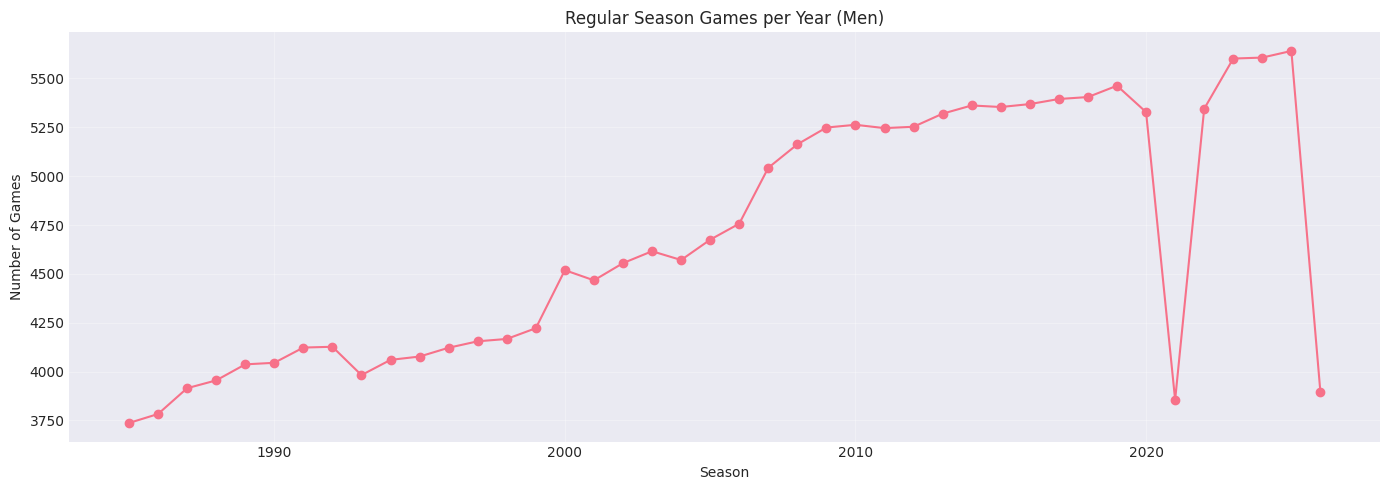

Average games per season: 4686
Min: 3737 (Season 1985)
Max: 5641 (Season 2025)


In [11]:
# Games per season
games_per_season = regular_m.groupby('Season').size()

plt.figure(figsize=(14, 5))
plt.plot(games_per_season.index, games_per_season.values, marker='o')
plt.xlabel('Season')
plt.ylabel('Number of Games')
plt.title('Regular Season Games per Year (Men)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Average games per season: {games_per_season.mean():.0f}")
print(f"Min: {games_per_season.min()} (Season {games_per_season.idxmin()})")
print(f"Max: {games_per_season.max()} (Season {games_per_season.idxmax()})")

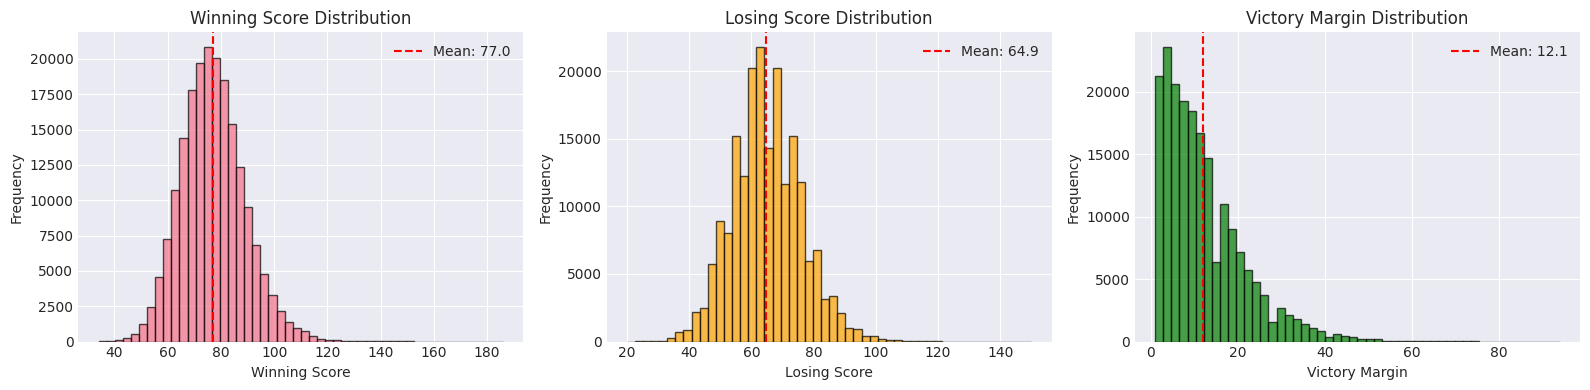

Close games (margin ≤ 3 points): 33,892 (17.2%)
Blowouts (margin > 20 points): 31,988 (16.3%)


In [12]:
# Score distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Winning scores
axes[0].hist(regular_m['WScore'], bins=50, alpha=0.7, edgecolor='black')
axes[0].axvline(regular_m['WScore'].mean(), color='red', linestyle='--', 
                label=f"Mean: {regular_m['WScore'].mean():.1f}")
axes[0].set_xlabel('Winning Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Winning Score Distribution')
axes[0].legend()

# Losing scores
axes[1].hist(regular_m['LScore'], bins=50, alpha=0.7, edgecolor='black', color='orange')
axes[1].axvline(regular_m['LScore'].mean(), color='red', linestyle='--',
                label=f"Mean: {regular_m['LScore'].mean():.1f}")
axes[1].set_xlabel('Losing Score')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Losing Score Distribution')
axes[1].legend()

# Victory margin
margin = regular_m['WScore'] - regular_m['LScore']
axes[2].hist(margin, bins=50, alpha=0.7, edgecolor='black', color='green')
axes[2].axvline(margin.mean(), color='red', linestyle='--',
                label=f"Mean: {margin.mean():.1f}")
axes[2].set_xlabel('Victory Margin')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Victory Margin Distribution')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Close games (margin ≤ 3 points): {(margin <= 3).sum():,} ({100*(margin <= 3).mean():.1f}%)")
print(f"Blowouts (margin > 20 points): {(margin > 20).sum():,} ({100*(margin > 20).mean():.1f}%)")

In [13]:
# Home court advantage
home_games = regular_m[regular_m['WLoc'] == 'H']
away_games = regular_m[regular_m['WLoc'] == 'A']
neutral_games = regular_m[regular_m['WLoc'] == 'N']

total_games = len(regular_m)
print("Game Location Distribution:")
print(f"  Home wins: {len(home_games):,} ({100*len(home_games)/total_games:.1f}%)")
print(f"  Away wins: {len(away_games):,} ({100*len(away_games)/total_games:.1f}%)")
print(f"  Neutral: {len(neutral_games):,} ({100*len(neutral_games)/total_games:.1f}%)")

# Home court advantage in margin
home_margin = home_games['WScore'] - home_games['LScore']
away_margin = away_games['WScore'] - away_games['LScore']

print(f"\nAverage victory margin:")
print(f"  Home team wins: {home_margin.mean():.2f} points")
print(f"  Away team wins: {away_margin.mean():.2f} points")

Game Location Distribution:
  Home wins: 116,270 (59.1%)
  Away wins: 60,435 (30.7%)
  Neutral: 20,118 (10.2%)

Average victory margin:
  Home team wins: 13.64 points
  Away team wins: 9.49 points


In [14]:
# Overtime analysis
ot_games = regular_m[regular_m['NumOT'] > 0]
print(f"Overtime Games: {len(ot_games):,} ({100*len(ot_games)/len(regular_m):.2f}%)")
print(f"\nOvertime Distribution:")
print(ot_games['NumOT'].value_counts().sort_index())

Overtime Games: 8,061 (4.10%)

Overtime Distribution:
NumOT
1    6711
2    1097
3     205
4      42
5       5
6       1
Name: count, dtype: int64


## 5. Tournament Games Analysis

In [20]:
# Load tournament results
tourney_m = load_tourney_results('M')

print("Tournament Games Sample:")
display(tourney_m.head(10))

check_data_quality(tourney_m, "Men's Tournament Games")

Tournament Games Sample:


,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT
0,1985,136,1116,63,1234,54,N,0
1,1985,136,1120,59,1345,58,N,0
2,1985,136,1207,68,1250,43,N,0
3,1985,136,1229,58,1425,55,N,0
4,1985,136,1242,49,1325,38,N,0
5,1985,136,1246,66,1449,58,N,0
6,1985,136,1256,78,1338,54,N,0
7,1985,136,1260,59,1233,58,N,0
8,1985,136,1314,76,1292,57,N,0
9,1985,136,1323,79,1333,70,N,0



Data Quality Report: Men's Tournament Games

Shape: 2,585 rows × 8 columns
Columns are:
Index(['Season', 'DayNum', 'WTeamID', 'WScore', 'LTeamID', 'LScore', 'WLoc',
       'NumOT'],
      dtype='str')


Column Types:
int64    7
str      1
Name: count, dtype: int64

Missing Values:
  No missing values ✓

Duplicate Rows: 0

Memory Usage: 0.26 MB




In [21]:
# Compare regular season vs tournament
print("REGULAR SEASON vs TOURNAMENT COMPARISON")
print("=" * 60)
print(f"\n{'Metric':<30} {'Regular':<15} {'Tournament':<15}")
print("-" * 60)

reg_margin = regular_m['WScore'] - regular_m['LScore']
tour_margin = tourney_m['WScore'] - tourney_m['LScore']

print(f"{'Avg Winning Score':<30} {regular_m['WScore'].mean():<15.2f} {tourney_m['WScore'].mean():<15.2f}")
print(f"{'Avg Losing Score':<30} {regular_m['LScore'].mean():<15.2f} {tourney_m['LScore'].mean():<15.2f}")
print(f"{'Avg Victory Margin':<30} {reg_margin.mean():<15.2f} {tour_margin.mean():<15.2f}")
print(f"{'Overtime %':<30} {100*(regular_m['NumOT']>0).mean():<15.2f} {100*(tourney_m['NumOT']>0).mean():<15.2f}")
print(f"{'Close games (≤3 pts) %':<30} {100*(reg_margin<=3).mean():<15.2f} {100*(tour_margin<=3).mean():<15.2f}")

REGULAR SEASON vs TOURNAMENT COMPARISON

Metric                         Regular         Tournament     
------------------------------------------------------------
Avg Winning Score              76.96           76.95          
Avg Losing Score               64.86           65.13          
Avg Victory Margin             12.10           11.82          
Overtime %                     4.10            5.84           
Close games (≤3 pts) %         17.22           17.60          


## 6. Tournament Seeds Analysis

In [22]:
# Load seeds
seeds_m = load_seeds('M')

print("Tournament Seeds Sample:")
display(seeds_m.head(10))

# Extract numeric seed
seeds_m['SeedNum'] = seeds_m['Seed'].str[1:3].astype(int)
seeds_m['Region'] = seeds_m['Seed'].str[0]

print("\nSeed Distribution:")
print(seeds_m['SeedNum'].value_counts().sort_index())

Tournament Seeds Sample:


,Season,Seed,TeamID
0,1985,W01,1207
1,1985,W02,1210
2,1985,W03,1228
3,1985,W04,1260
4,1985,W05,1374
5,1985,W06,1208
6,1985,W07,1393
7,1985,W08,1396
8,1985,W09,1439
9,1985,W10,1177



Seed Distribution:
SeedNum
1     160
2     160
3     160
4     160
5     160
6     160
7     160
8     160
9     160
10    162
11    180
12    164
13    161
14    161
15    160
16    198
Name: count, dtype: int64


In [18]:
# Teams per region
recent_season = seeds_m['Season'].max()
recent_seeds = seeds_m[seeds_m['Season'] == recent_season]

print(f"Most Recent Tournament ({recent_season}):")
print(f"Total teams: {len(recent_seeds)}")
print(f"\nTeams per region:")
print(recent_seeds['Region'].value_counts())

Most Recent Tournament (2025):
Total teams: 68

Teams per region:
Region
Y    18
W    17
X    17
Z    16
Name: count, dtype: int64


## 7. Save Summary Statistics

In [19]:
# Create summary statistics DataFrame
summary_stats = []

for season in sorted(regular_m['Season'].unique()):
    stats = get_season_summary(regular_m, season)
    summary_stats.append(stats)

summary_df = pd.DataFrame(summary_stats)

# Save to processed/ (uses automatic path detection from src.data_loader)
from src.data_loader import PROCESSED_DIR
output_path = PROCESSED_DIR / 'basic_stats.csv'
summary_df.to_csv(output_path, index=False)
print(f"✓ Saved summary statistics to {output_path}")

display(summary_df.tail(10))

✓ Saved summary statistics to /home/sagemaker-user/NCAA/NCAA_March_Maddness-2026/processed/basic_stats.csv


,season,num_games,num_teams,avg_winning_score,avg_losing_score,avg_margin,num_overtimes,overtime_pct
32,2017,5395,351,78.645783,66.615199,12.030584,408,6.209453
33,2018,5405,351,79.080296,66.919149,12.161147,421,6.530990
34,2019,5463,353,77.887424,65.790591,12.096833,14,0.237964
35,2020,5328,353,76.177928,64.230105,11.947823,358,5.574324
36,2021,3855,347,76.808301,64.807004,12.001297,260,5.525292
37,2022,5345,358,75.920112,64.170627,11.749486,377,5.855940
38,2023,5602,363,76.618886,64.871831,11.747055,405,6.265619
39,2024,5607,362,78.645086,66.572677,12.072409,392,5.974675
40,2025,5641,364,78.875199,66.683921,12.191278,382,5.584116
41,2026,3893,365,81.570768,68.356281,13.214488,253,5.497046


## 8. Key Takeaways

**Write your observations here after running the analysis:**

1. Data coverage: 
   - For M teams we have about 5600 GAMES very season played by 365 TEAMS. We have the regular season and tournament season stats
   
2. Game patterns:
   - We have Avg Winning points of 81.57 annd Avg Losing points of ~68.36-66.68
   
3. Home court advantage:
   - We have significant  Home team advantage of about 60% wins
   
4. Tournament vs Regular season:
   - Very similar but fewer games and winning margin as smaller in tournament games
   
5. Next steps:
   - Move to `02_eda_tournaments.ipynb` for seed analysis
   - Investigate specific teams or seasons of interest